<a href="https://colab.research.google.com/github/hanifsidhartha26/AI_Career_Coach/blob/main/Breast_Cancer_ML_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Breast Cancer Prediction

In [3]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)

RANDOM_STATE = 42
pd.set_option("display.max_columns", None)

## Task 1: Data Exploration

In [4]:
df = pd.read_csv("breast_cancer_dataset.csv")
print("Shape:", df.shape)
display(df.head())
df.info()

Shape: (569, 32)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

,Count,Percentage
diagnosis,,
B,357,62.741652
M,212,37.258348


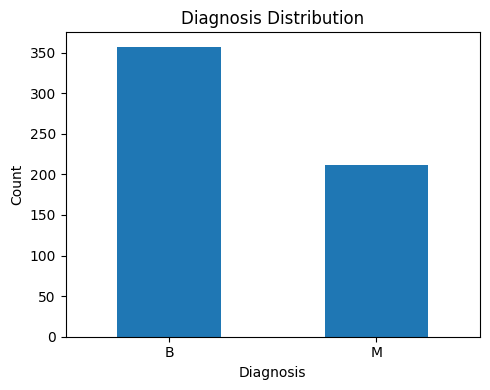

In [5]:
target_summary = pd.DataFrame({
    "Count": df["diagnosis"].value_counts(),
    "Percentage": df["diagnosis"].value_counts(normalize=True).mul(100)
})
display(target_summary)

target_summary.loc[["B", "M"], "Count"].plot(kind="bar", figsize=(5, 4))
plt.title("Diagnosis Distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [6]:
features = [c for c in df.select_dtypes(include=np.number).columns if c != "id"]
stats = pd.DataFrame({
    "Mean": df[features].mean(),
    "Median": df[features].median(),
    "Std": df[features].std()
})
display(stats)

,Mean,Median,Std
radius_mean,14.127292,13.370000,3.524049
texture_mean,19.289649,18.840000,4.301036
perimeter_mean,91.969033,86.240000,24.298981
area_mean,654.889104,551.100000,351.914129
smoothness_mean,0.096360,0.095870,0.014064
compactness_mean,0.104341,0.092630,0.052813
concavity_mean,0.088799,0.061540,0.079720
concave points_mean,0.048919,0.033500,0.038803
symmetry_mean,0.181162,0.179200,0.027414
fractal_dimension_mean,0.062798,0.061540,0.007060


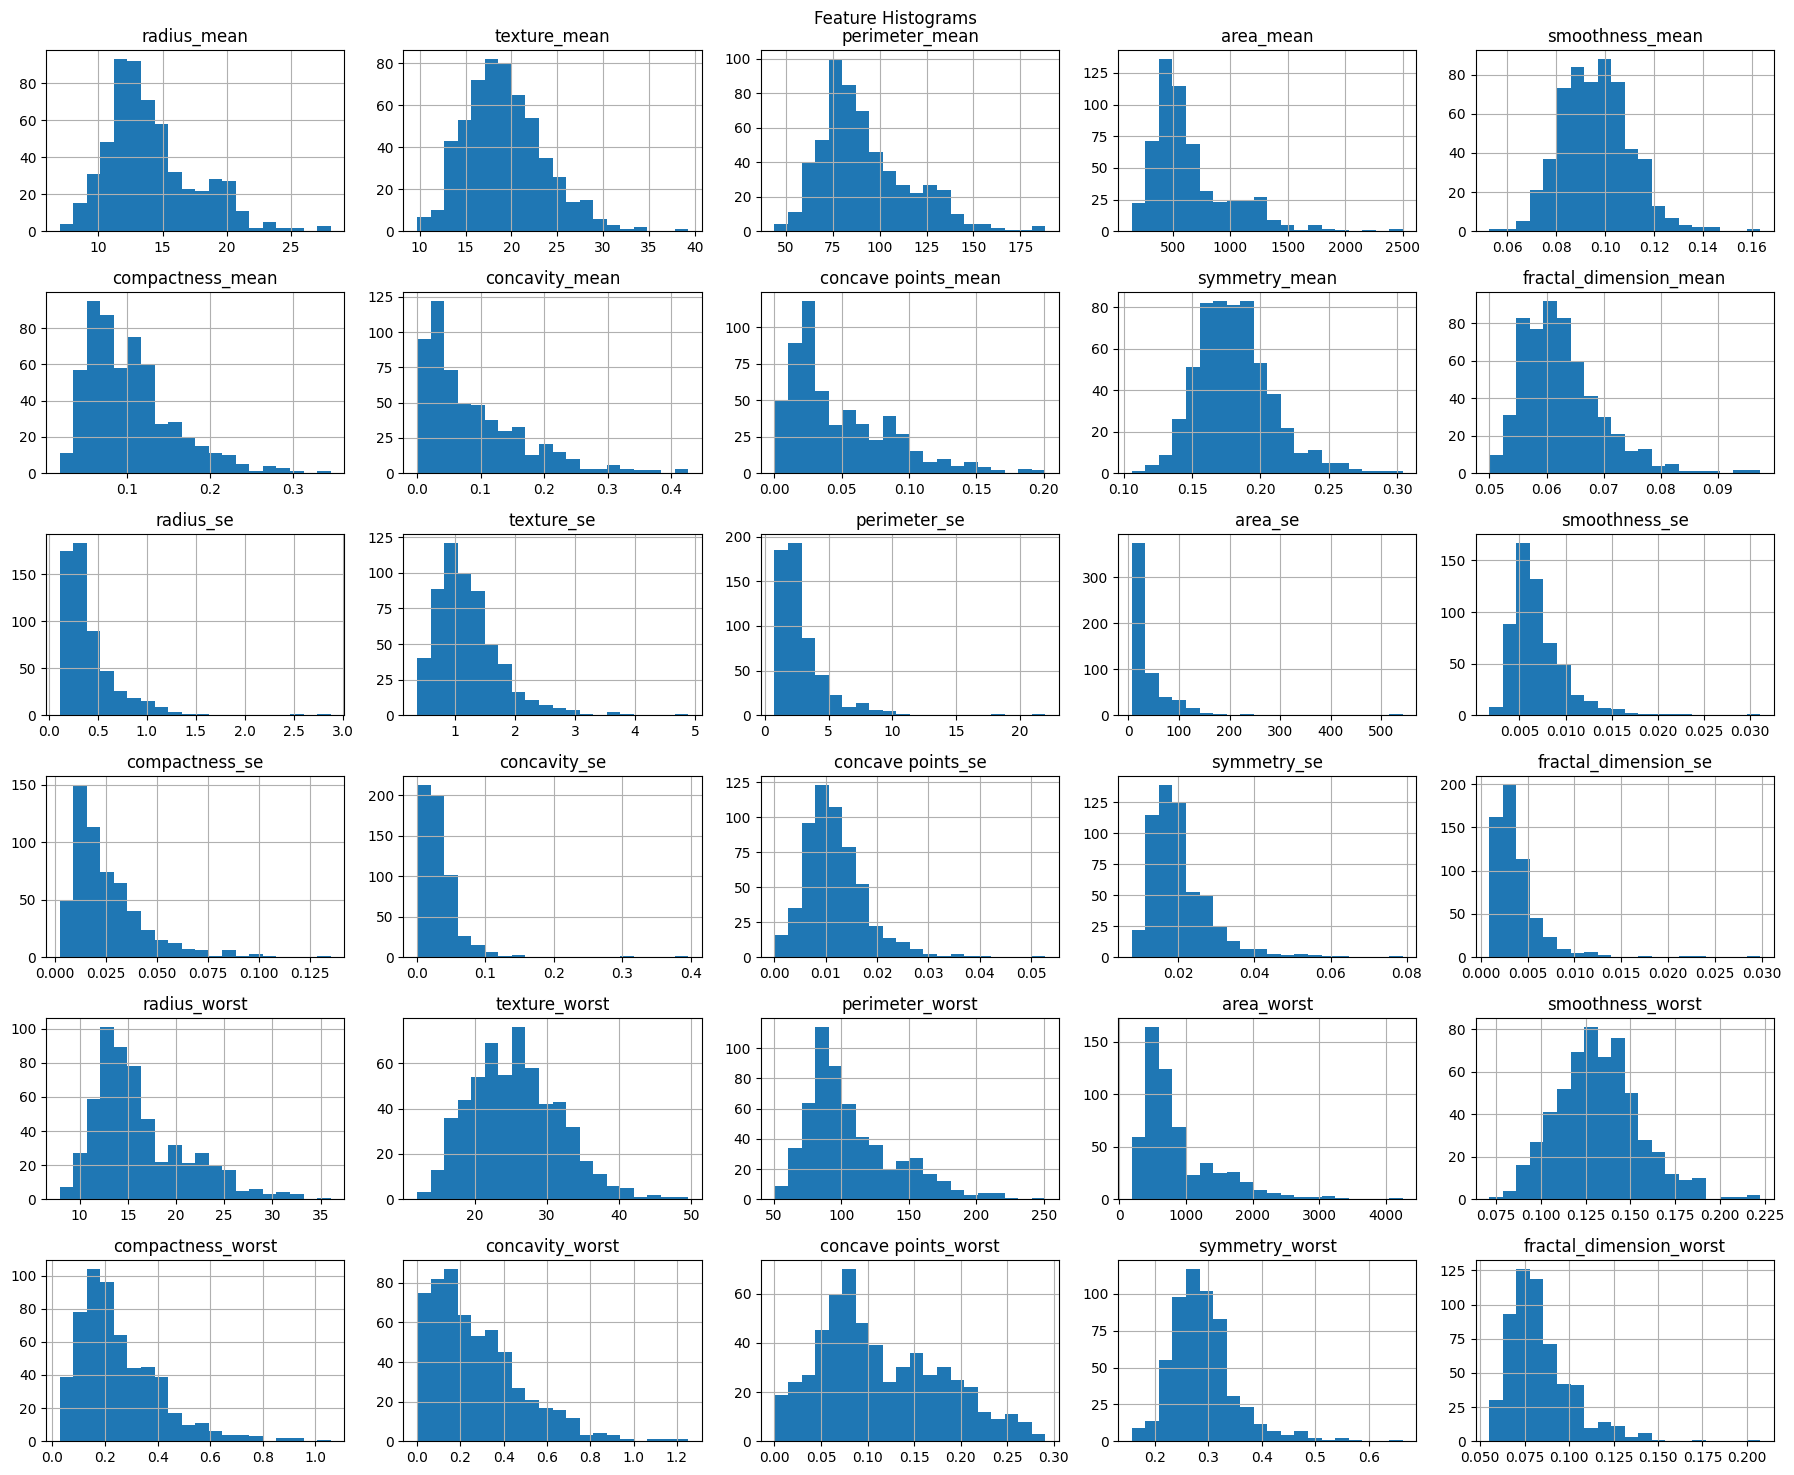

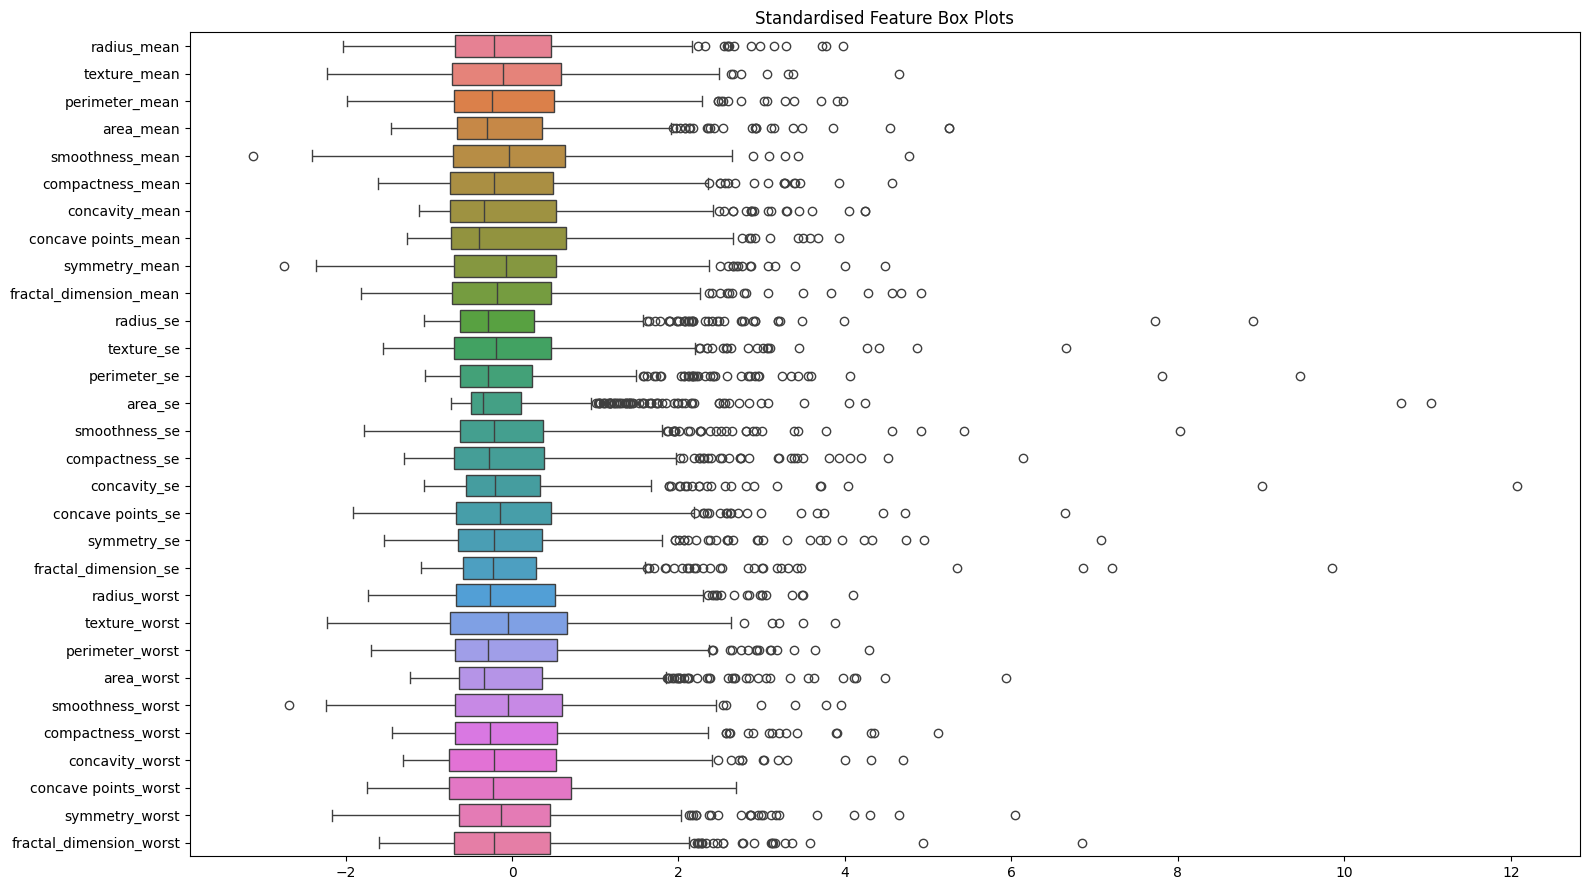

In [7]:
df[features].hist(figsize=(18, 15), bins=20)
plt.suptitle("Feature Histograms")
plt.tight_layout()
plt.show()

scaled_plot = pd.DataFrame(StandardScaler().fit_transform(df[features]), columns=features)
plt.figure(figsize=(16, 9))
sns.boxplot(data=scaled_plot, orient="h")
plt.title("Standardised Feature Box Plots")
plt.tight_layout()
plt.show()

,Correlation with diagnosis
concave points_worst,0.793566
perimeter_worst,0.782914
concave points_mean,0.776614
radius_worst,0.776454
perimeter_mean,0.742636
area_worst,0.733825
radius_mean,0.730029
area_mean,0.708984
concavity_mean,0.696360
concavity_worst,0.659610


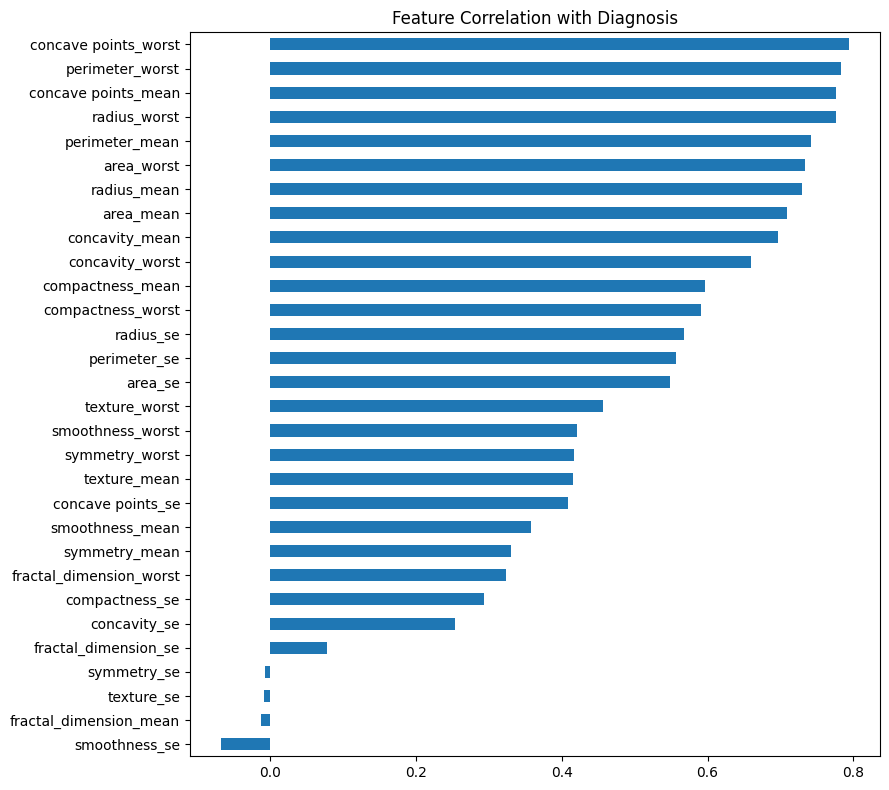

In [8]:
y_corr = df["diagnosis"].map({"B": 0, "M": 1})
corr_df = df[features].copy()
corr_df["diagnosis"] = y_corr

target_corr = corr_df.corr()["diagnosis"].drop("diagnosis").sort_values(key=abs, ascending=False)
display(target_corr.to_frame("Correlation with diagnosis"))

plt.figure(figsize=(9, 8))
target_corr.sort_values().plot(kind="barh")
plt.title("Feature Correlation with Diagnosis")
plt.tight_layout()
plt.show()

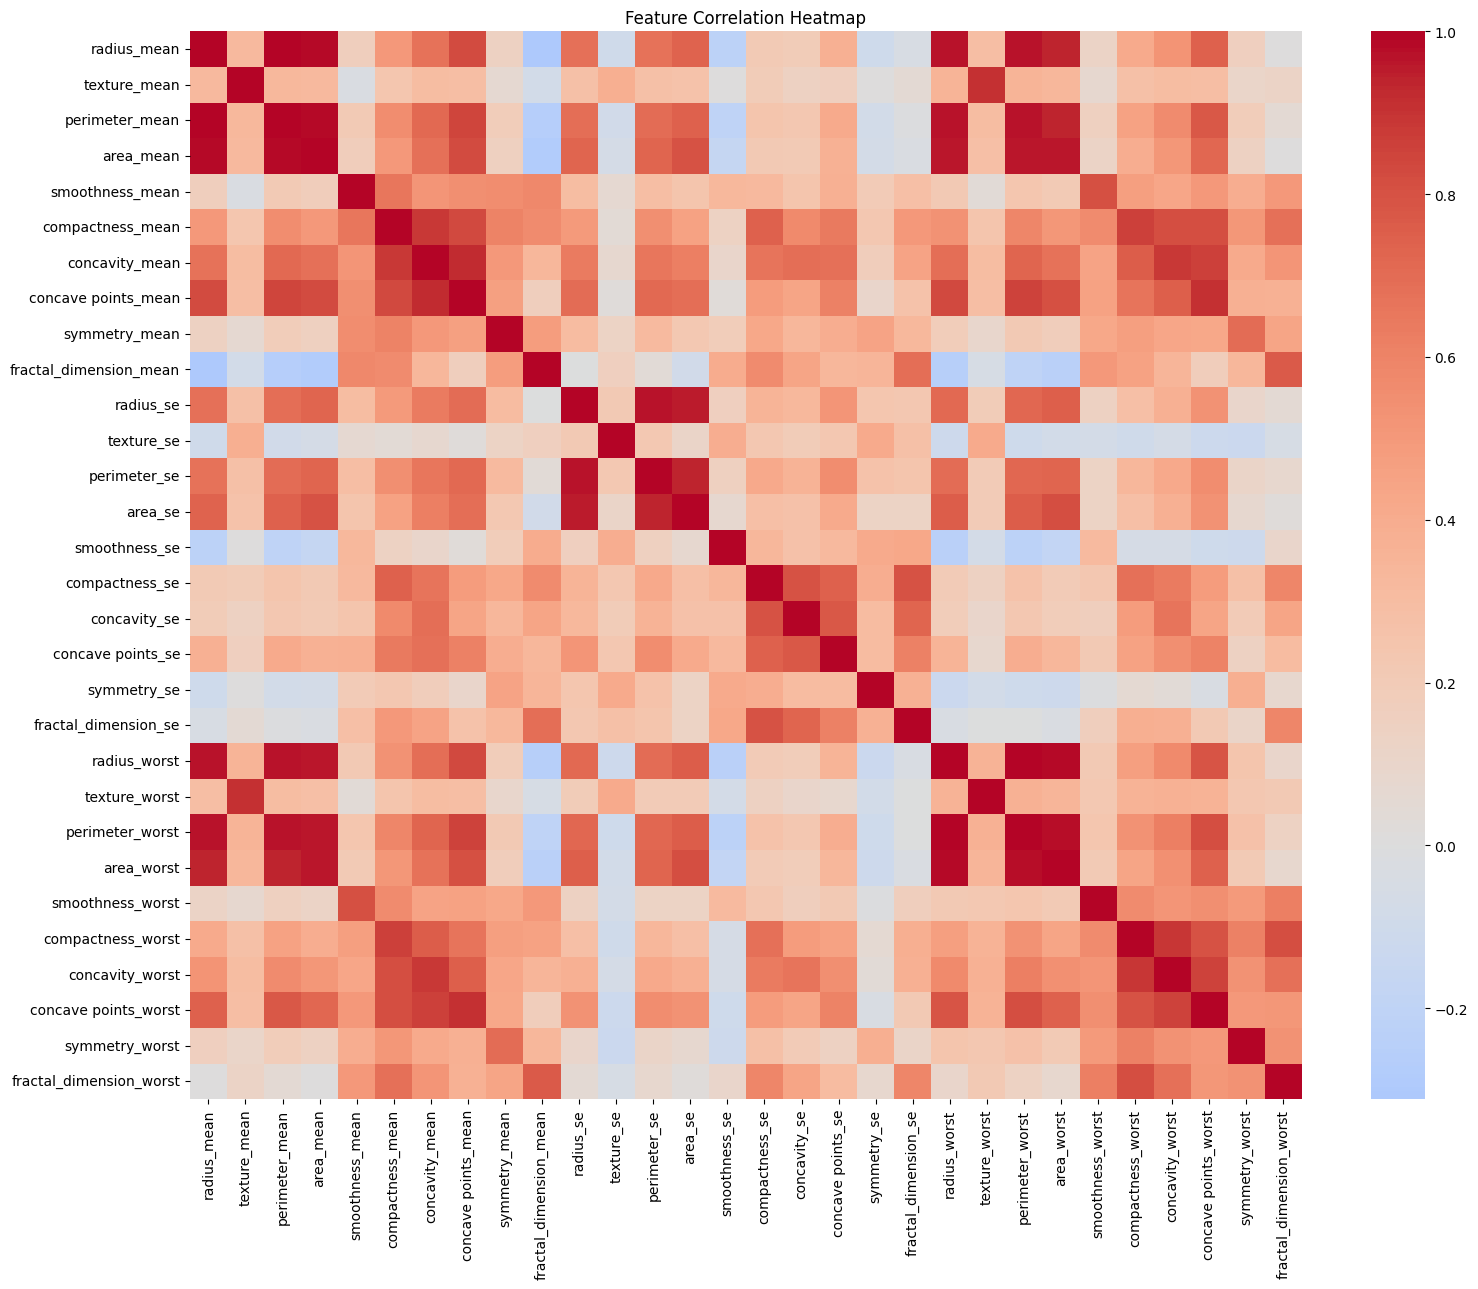

,Feature 1,Feature 2,|Correlation|
1,radius_mean,perimeter_mean,0.997855
391,radius_worst,perimeter_worst,0.993708
2,radius_mean,area_mean,0.987357
57,perimeter_mean,area_mean,0.986507
392,radius_worst,area_worst,0.984015
407,perimeter_worst,area_worst,0.977578
246,radius_se,perimeter_se,0.972794
76,perimeter_mean,perimeter_worst,0.970387
19,radius_mean,radius_worst,0.969539
74,perimeter_mean,radius_worst,0.969476


In [9]:
feature_corr = df[features].corr()
plt.figure(figsize=(16, 13))
sns.heatmap(feature_corr, cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

upper = feature_corr.abs().where(np.triu(np.ones(feature_corr.shape), k=1).astype(bool))
strong_pairs = (
    upper.stack().reset_index()
    .rename(columns={"level_0": "Feature 1", "level_1": "Feature 2", 0: "|Correlation|"})
    .query("`|Correlation|` >= 0.90")
    .sort_values("|Correlation|", ascending=False)
)
display(strong_pairs)

## Task 2: Data Preparation

In [10]:
X = df.drop(columns=["diagnosis", "id"])
y = df["diagnosis"].map({"B": 0, "M": 1})

missing = df.isna().sum()
display(missing[missing > 0].to_frame("Missing values"))
print("Total missing values:", missing.sum())

,Missing values


Total missing values: 0


No missing values are present. Median imputation is retained in the pipelines as a reproducible strategy. StandardScaler is used so numerical features share a comparable scale.

## Task 3: Model Training

An 80:20 stratified split is used so most observations train the models while 20% remain unseen for final evaluation. Stratification preserves the malignant/benign proportions.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
print("Training:", X_train.shape, "Testing:", X_test.shape)

Training: (455, 30) Testing: (114, 30)


In [12]:
classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=5000, random_state=RANDOM_STATE),
    "SVM": SVC(probability=True, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE),
    "KNN": KNeighborsClassifier()
}

models = {
    name: Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("classifier", clf)
    ])
    for name, clf in classifiers.items()
}

default_params = pd.DataFrame({
    "Model": ["Logistic Regression", "SVM", "Decision Tree", "Random Forest", "KNN"],
    "Initial hyperparameters": [
        "C=1.0, solver=lbfgs, penalty=l2",
        "C=1.0, kernel=rbf, gamma=scale",
        "criterion=gini, max_depth=None, min_samples_split=2",
        "n_estimators=100, criterion=gini, max_depth=None",
        "n_neighbors=5, weights=uniform, p=2"
    ]
})
display(default_params)

for model in models.values():
    model.fit(X_train, y_train)

,Model,Initial hyperparameters
0,Logistic Regression,"C=1.0, solver=lbfgs, penalty=l2"
1,SVM,"C=1.0, kernel=rbf, gamma=scale"
2,Decision Tree,"criterion=gini, max_depth=None, min_samples_sp..."
3,Random Forest,"n_estimators=100, criterion=gini, max_depth=None"
4,KNN,"n_neighbors=5, weights=uniform, p=2"


## Task 4: Model Evaluation and Tuning

,Accuracy,Precision,Recall,F1,AUC
Logistic Regression,0.9649,0.9750,0.9286,0.9512,0.9960
SVM,0.9737,1.0000,0.9286,0.9630,0.9947
Decision Tree,0.9298,0.9048,0.9048,0.9048,0.9246
Random Forest,0.9737,1.0000,0.9286,0.9630,0.9929
KNN,0.9561,0.9744,0.9048,0.9383,0.9823


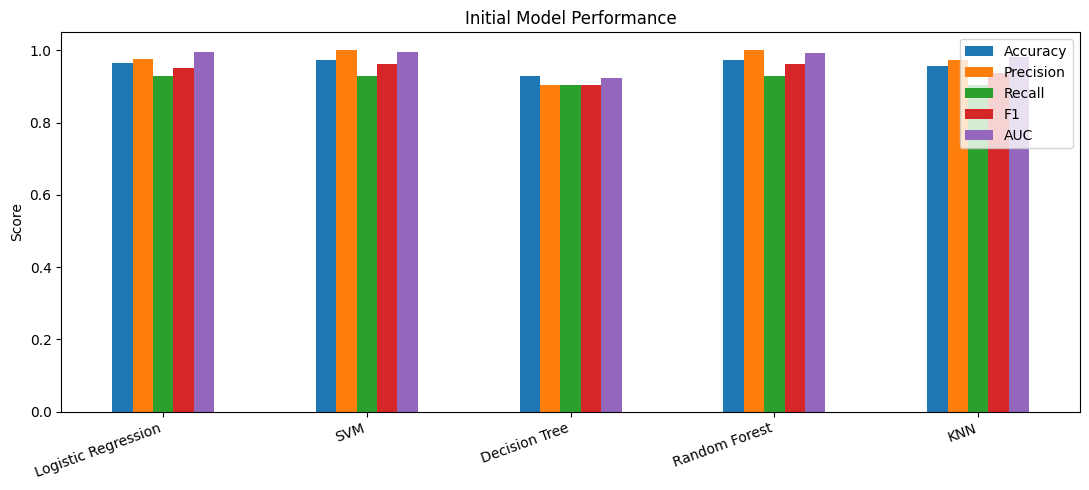

In [13]:
def metrics(model, X_data, y_data):
    pred = model.predict(X_data)
    prob = model.predict_proba(X_data)[:, 1]
    return {
        "Accuracy": accuracy_score(y_data, pred),
        "Precision": precision_score(y_data, pred),
        "Recall": recall_score(y_data, pred),
        "F1": f1_score(y_data, pred),
        "AUC": roc_auc_score(y_data, prob)
    }

initial_results = pd.DataFrame({
    name: metrics(model, X_test, y_test)
    for name, model in models.items()
}).T
display(initial_results.round(4))

initial_results.plot(kind="bar", figsize=(11, 5))
plt.title("Initial Model Performance")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

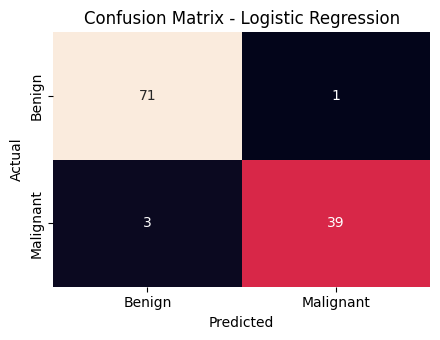

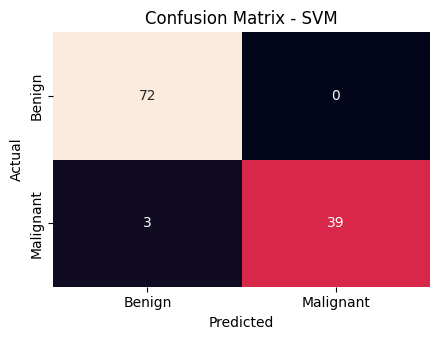

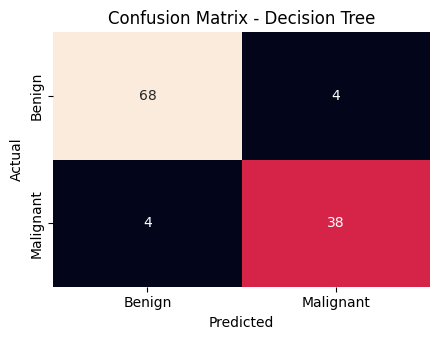

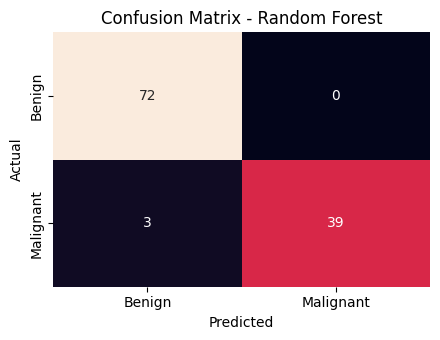

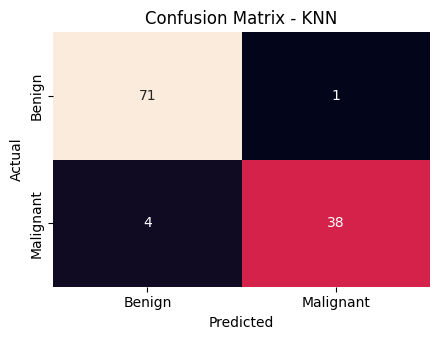

In [14]:
for name, model in models.items():
    cm = confusion_matrix(y_test, model.predict(X_test))
    plt.figure(figsize=(4.5, 3.5))
    sns.heatmap(cm, annot=True, fmt="d", cbar=False,
                xticklabels=["Benign", "Malignant"],
                yticklabels=["Benign", "Malignant"])
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

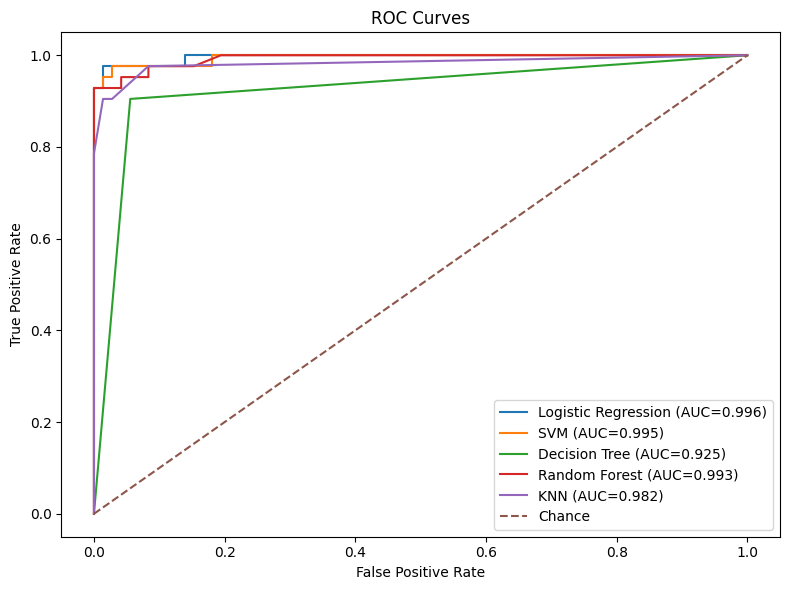

In [15]:
plt.figure(figsize=(8, 6))
for name, model in models.items():
    prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, prob):.3f})")
plt.plot([0, 1], [0, 1], "--", label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.tight_layout()
plt.show()

The model for tuning is selected using 5-fold stratified cross-validation on the training set. The test set is therefore not used for model selection.

In [16]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
    cv_results[name] = [scores.mean(), scores.std()]

cv_table = pd.DataFrame(cv_results, index=["Mean CV AUC", "Std CV AUC"]).T.sort_values("Mean CV AUC", ascending=False)
display(cv_table.round(4))

best_name = cv_table.index[0]
print("Selected for tuning:", best_name)

,Mean CV AUC,Std CV AUC
Logistic Regression,0.9958,0.0047
SVM,0.9949,0.0050
Random Forest,0.9889,0.0067
KNN,0.9871,0.0136
Decision Tree,0.9172,0.0375


Selected for tuning: Logistic Regression


In [17]:
param_grids = {
    "Logistic Regression": {
        "classifier__C": [0.01, 0.1, 1, 10, 100],
        "classifier__solver": ["liblinear", "lbfgs"]
    },
    "SVM": {
        "classifier__C": [0.1, 1, 10, 100],
        "classifier__kernel": ["linear", "rbf"],
        "classifier__gamma": ["scale", "auto"]
    },
    "Decision Tree": {
        "classifier__criterion": ["gini", "entropy"],
        "classifier__max_depth": [None, 3, 5, 8, 12],
        "classifier__min_samples_split": [2, 5, 10],
        "classifier__min_samples_leaf": [1, 2, 4]
    },
    "Random Forest": {
        "classifier__n_estimators": [100, 200, 300],
        "classifier__max_depth": [None, 5, 10],
        "classifier__min_samples_split": [2, 5],
        "classifier__min_samples_leaf": [1, 2]
    },
    "KNN": {
        "classifier__n_neighbors": [3, 5, 7, 9, 11],
        "classifier__weights": ["uniform", "distance"],
        "classifier__p": [1, 2]
    }
}

grid = GridSearchCV(
    models[best_name], param_grids[best_name],
    scoring="roc_auc", cv=cv, n_jobs=-1, refit=True
)
grid.fit(X_train, y_train)
tuned_model = grid.best_estimator_

print("Best parameters:", grid.best_params_)
print("Best CV AUC:", round(grid.best_score_, 4))

Best parameters: {'classifier__C': 1, 'classifier__solver': 'liblinear'}
Best CV AUC: 0.9959


,Accuracy,Precision,Recall,F1,AUC
Logistic Regression Before Tuning,0.9649,0.9750,0.9286,0.9512,0.996
Logistic Regression After Tuning,0.9737,0.9756,0.9524,0.9639,0.996


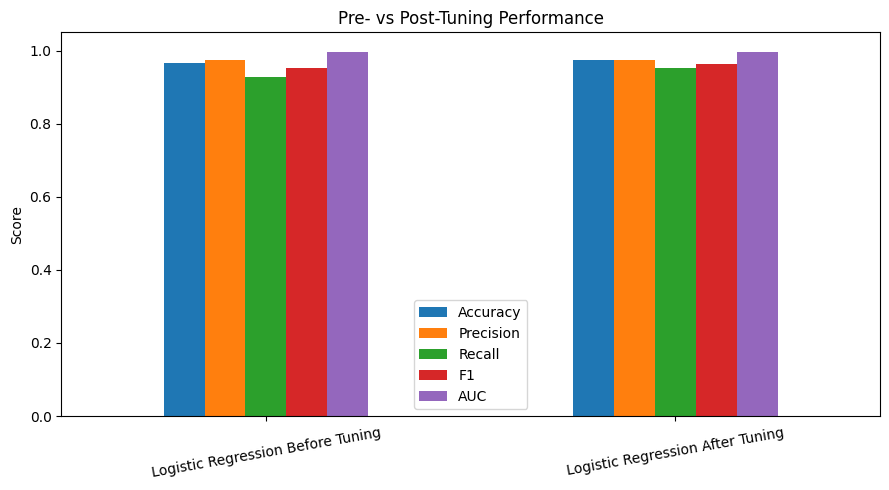

,Change
Accuracy,0.0088
Precision,0.0006
Recall,0.0238
F1,0.0126
AUC,0.0000


In [18]:
before = metrics(models[best_name], X_test, y_test)
after = metrics(tuned_model, X_test, y_test)

comparison = pd.DataFrame(
    [before, after],
    index=[f"{best_name} Before Tuning", f"{best_name} After Tuning"]
)
display(comparison.round(4))

comparison.plot(kind="bar", figsize=(9, 5))
plt.title("Pre- vs Post-Tuning Performance")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

change = comparison.iloc[1] - comparison.iloc[0]
display(change.to_frame("Change").round(4))

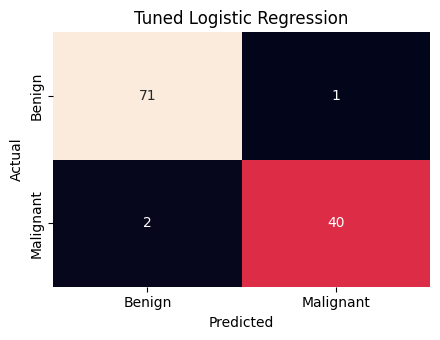

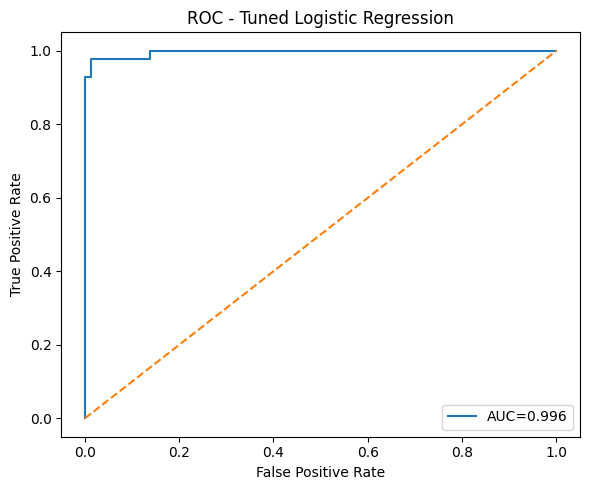

              precision    recall  f1-score   support

      Benign       0.97      0.99      0.98        72
   Malignant       0.98      0.95      0.96        42

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



In [19]:
pred = tuned_model.predict(X_test)
prob = tuned_model.predict_proba(X_test)[:, 1]

plt.figure(figsize=(4.5, 3.5))
sns.heatmap(confusion_matrix(y_test, pred), annot=True, fmt="d", cbar=False,
            xticklabels=["Benign", "Malignant"], yticklabels=["Benign", "Malignant"])
plt.title(f"Tuned {best_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

fpr, tpr, _ = roc_curve(y_test, prob)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC={roc_auc_score(y_test, prob):.3f}")
plt.plot([0, 1], [0, 1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC - Tuned {best_name}")
plt.legend()
plt.tight_layout()
plt.show()

print(classification_report(y_test, pred, target_names=["Benign", "Malignant"]))

In [20]:
clf = tuned_model.named_steps["classifier"]

if hasattr(clf, "feature_importances_"):
    importance = pd.Series(clf.feature_importances_, index=X.columns).sort_values(ascending=False)
    display(importance.head(10).to_frame("Importance"))
elif hasattr(clf, "coef_"):
    importance = pd.Series(np.abs(clf.coef_[0]), index=X.columns).sort_values(ascending=False)
    display(importance.head(10).to_frame("Absolute coefficient"))
else:
    display(target_corr.abs().sort_values(ascending=False).head(10).to_frame("|Correlation with diagnosis|"))

,Absolute coefficient
texture_worst,1.423806
radius_se,1.243632
symmetry_worst,1.059102
concave points_mean,0.954814
area_se,0.933406
area_worst,0.924092
compactness_se,0.915840
concavity_worst,0.910627
radius_worst,0.896585
concavity_mean,0.790535


## Task 5: Conclusion and Future Work

In [21]:
best_initial_test = initial_results["AUC"].idxmax()
delta = comparison.iloc[1] - comparison.iloc[0]

print("Top initial test AUC:", best_initial_test)
print("Model selected by training CV:", best_name)
print("\nFinal tuned metrics:")
display(comparison.iloc[[1]].round(4))

improved = [m for m in change.index if change[m] > 0]
decreased = [m for m in change.index if change[m] < 0]
unchanged = [m for m in change.index if change[m] == 0]

print("Improved metrics:", ", ".join(improved) if improved else "None")
print("Decreased metrics:", ", ".join(decreased) if decreased else "None")
print("Unchanged metrics:", ", ".join(unchanged) if unchanged else "None")
print("\nConstraints: results are based on the supplied sample and available diagnostic features.")
print("Generalisability: independent external datasets/populations should be used for validation.")
print("Future work: feature engineering and advanced models such as neural networks could be examined.")
print("Medical use: explainability should be considered so predictions can be interpreted.")

Top initial test AUC: Logistic Regression
Model selected by training CV: Logistic Regression

Final tuned metrics:


,Accuracy,Precision,Recall,F1,AUC
Logistic Regression After Tuning,0.9737,0.9756,0.9524,0.9639,0.996


Improved metrics: Accuracy, Precision, Recall, F1
Decreased metrics: None
Unchanged metrics: AUC

Constraints: results are based on the supplied sample and available diagnostic features.
Generalisability: independent external datasets/populations should be used for validation.
Future work: feature engineering and advanced models such as neural networks could be examined.
Medical use: explainability should be considered so predictions can be interpreted.
